# Random Forest Classifier

In this notebook I use a Random Forest classifier to predict whether Player 1 wins a tennis match.

The model is trained on the same training set used for the ANN and evaluated on the 2023 validation set.

Different Random Forest configurations are tested in order to fine-tune the model parameters.

In [1]:
from pathlib import Path 

import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    log_loss, 
    confusion_matrix, 
    classification_report
)

In [2]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = ( PROCESSED_DATA_DIR / "feature_split_matches.csv")

matches = pd.read_csv(
    input_file, parse_dates=["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)

print(matches["DataSplit"].value_counts())

Dataset shape: (26536, 49)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [3]:
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

print( 
    "Training:", 
    train_data["Date"].min(), 
    "-", 
    train_data["Date"].max()
)

print(
    "Validation:", 
    validation_data["Date"].min(),
    "-", 
    validation_data["Date"].max()
)

print(
    "Test:", 
    test_data["Date"].min(), 
    "-", 
    test_data["Date"].max()
)

Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validation: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Test: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [4]:
numeric_features = [
    "Player1Rank",
    "Player2Rank",
    "Player1Points",
    "Player2Points",

    "Player1MatchesBefore",
    "Player2MatchesBefore",
    "ExperienceDifference",

    "Player1WinRateBefore",
    "Player2WinRateBefore",
    "WinRateDifference",

    "Player1Recent5WinRate",
    "Player2Recent5WinRate",
    "Recent5WinRateDifference",

    "Player1SurfaceMatchesBefore",
    "Player2SurfaceMatchesBefore",

    "Player1SurfaceWinRateBefore",
    "Player2SurfaceWinRateBefore",
    "SurfaceWinRateDifference",

    "H2HMatchesBefore",
    "Player1H2HWinRateBefore",
    "Player2H2HWinRateBefore",
    "DifferenceH2HWinRateBefore",

    "Player1DaysSinceLastMatch",
    "Player2DaysSinceLastMatch",

    "RankDifference",
    "PointsDifference"
]

In [5]:
X_train = train_data[numeric_features].copy()
X_validation = validation_data[numeric_features].copy()
y_train = train_data["Player1Won"].to_numpy()
y_validation = validation_data["Player1Won"].to_numpy()

print("Training X:", X_train.shape)
print("Validation X:", X_validation.shape)
print("Training y:", y_train.shape)
print("Validation y:", y_validation.shape)

Training X: (18810, 26)
Validation X: (2607, 26)
Training y: (18810,)
Validation y: (2607,)


In [6]:
training_medians = X_train.median()

X_train = X_train.fillna(training_medians)
X_validation = X_validation.fillna(training_medians)

print("Missing training values:", X_train.isna().sum().sum())
print("Missing validation values:", X_validation.isna().sum().sum())


Missing training values: 0
Missing validation values: 0


Unlike the ANN, I do not standardize the features for the Random Forest.

A Random Forest divides the data using thresholds on individual
features. Therefore the different numerical scales of the features
do not have the same effect that they have in a neural network.

In [7]:
model = RandomForestClassifier(
    n_estimators = 100, 
    max_depth = None, 
    min_samples_leaf=1, 
    max_features="sqrt",
    random_state=42, 
    n_jobs=-1 #This tells scikit-learn to use all available processor cores when possible.
    #It changes speed, not the mathematical model.
)

In [8]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
validation_predictions = model.predict(X_validation)

In [10]:
validation_probabilities = (
    model.predict_proba(X_validation)[:, 1]
)

In [11]:
initial_results = pd.DataFrame(
    {
        "Model": ["Initial Random Forest"], 
        "Accuracy": [
            accuracy_score(
                y_validation, 
                validation_predictions
            )
        ],
        "BalancedAccuracy": [
            balanced_accuracy_score(
                y_validation, 
                validation_predictions
            )
        ], 
        "Precision": [
            precision_score(
                y_validation, 
                validation_predictions, 
                zero_division=0
            )
        ], 
        "Recall": [
            recall_score(
                y_validation, 
                validation_predictions,
                zero_division=0
            )
        ], 
        "F1": [
            f1_score(
                y_validation, 
                validation_predictions, 
                zero_division=0
            )
        ], 
        "ROC_AUC" : [
            roc_auc_score(
                y_validation, 
                validation_probabilities
            )
        ], 
        "LogLoss": [
            log_loss(
                y_validation, 
                validation_probabilities
            )
        ]  
        
    }
)

initial_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,Initial Random Forest,0.624089,0.623851,0.601569,0.619048,0.610183,0.684589,0.637336


In [12]:
print(
    classification_report(
        y_validation, 
        validation_predictions, 
        target_names=[
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division=0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.65      0.63      0.64      1368
Player 1 wins       0.60      0.62      0.61      1239

     accuracy                           0.62      2607
    macro avg       0.62      0.62      0.62      2607
 weighted avg       0.62      0.62      0.62      2607



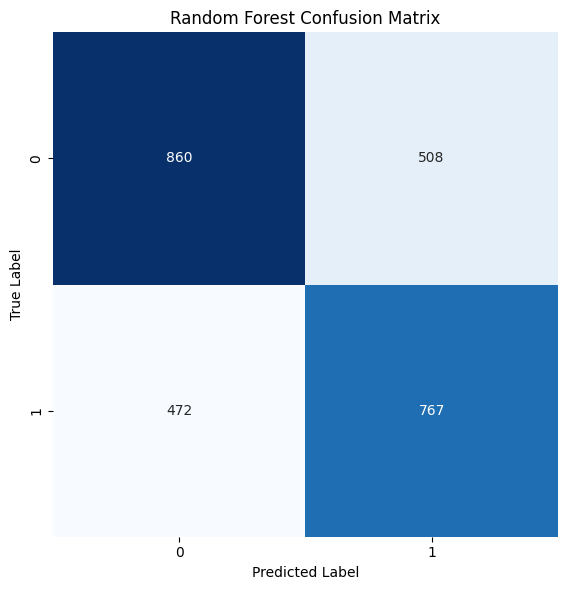

In [13]:
matrix = confusion_matrix(
    y_validation, 
    validation_predictions
)

fig, axes = plt.subplots(
    figsize=(6, 6), 
    tight_layout=True
)

sns.heatmap(
    matrix, 
    square=True, 
    annot=True, 
    fmt="d", 
    cbar=False, 
    cmap="Blues"
)

axes.set_xlabel("Predicted Label")
axes.set_ylabel("True Label")
axes.set_title("Random Forest Confusion Matrix")
plt.show()

In [14]:
configurations = [
    {
        "name": "RF 100", 
        "n_estimators": 100, 
        "max_depth": None, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200", 
        "n_estimators": 200, 
        "max_depth": None, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200 depth 10", 
        "n_estimators": 200, 
        "max_depth": 10, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 200 depth 15", 
        "n_estimators": 200, 
        "max_depth": 15, 
        "min_samples_leaf": 1
    },
    {
        "name": "RF 300 depth 10 leaf 2", 
        "n_estimators": 300, 
        "max_depth": 10, 
        "min_samples_leaf": 2
    },
    {
        "name": "RF 300 depth 15 leaf 2", 
        "n_estimators": 300, 
        "max_depth": 15, 
        "min_samples_leaf": 2
    }
]

In [15]:
# train every configuration 
tuning_results = []
trained_models = {}

for configuration in configurations:
    
    print("\nTraining:", configuration["name"])
    
    current_model = RandomForestClassifier(
        n_estimators= configuration["n_estimators"],
        max_depth= configuration["max_depth"], 
        min_samples_leaf= configuration["min_samples_leaf"],
        max_features="sqrt", 
        random_state=42, 
        n_jobs=-1
    )
    
    current_model.fit(X_train, y_train)
    
    current_predictions = (
        current_model.predict(X_validation)
    )
    
    current_probabilities = (
        current_model.predict_proba(X_validation)[:, 1]
    )
    
    current_accuracy = accuracy_score(
        y_validation, 
        current_predictions
    )
    
    current_balanced_accuracy = balanced_accuracy_score(
        y_validation, 
        current_predictions
    )
    
    current_precision = precision_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )
    
    current_recall = recall_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )
    
    current_f1 = f1_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )
    
    current_roc_auc = roc_auc_score(
        y_validation, 
        current_probabilities
    )
    
    current_log_loss = log_loss(
        y_validation, 
        current_probabilities
    )
    
    tuning_results.append(
        {
            "Model": configuration["name"], 
            "NumberOfTrees": configuration["n_estimators"], 
            "MaxDepth": configuration["max_depth"], 
            "MinSamplesLeaf": configuration["min_samples_leaf"], 
            "Accuracy": current_accuracy, 
            "BalancedAccuracy": current_balanced_accuracy, 
            "Precision": current_precision, 
            "Recall": current_recall, 
            "F1": current_f1, 
            "ROC_AUC": current_roc_auc, 
            "LogLoss": current_log_loss
        }
    )
    
    trained_models[configuration["name"]] = current_model
    
    print("Validation accuracy:", round(current_accuracy, 4))
    


Training: RF 100


Validation accuracy: 0.6241

Training: RF 200


Validation accuracy: 0.6314

Training: RF 200 depth 10


Validation accuracy: 0.639

Training: RF 200 depth 15


Validation accuracy: 0.6367

Training: RF 300 depth 10 leaf 2


Validation accuracy: 0.6367

Training: RF 300 depth 15 leaf 2


Validation accuracy: 0.6387


In [16]:
tuning_results = pd.DataFrame(tuning_results)

tuning_results = (
    tuning_results.sort_values(
        by=["Accuracy", "ROC_AUC"], 
        ascending=[False, False]
    ).reset_index(drop=True)
)

tuning_results

,Model,NumberOfTrees,MaxDepth,MinSamplesLeaf,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,RF 200 depth 10,200,10.0,1,0.639049,0.639285,0.614792,0.644068,0.629089,0.702871,0.625568
1,RF 300 depth 15 leaf 2,300,15.0,2,0.638665,0.638653,0.615564,0.638418,0.626783,0.696841,0.629398
2,RF 300 depth 10 leaf 2,300,10.0,2,0.636747,0.636902,0.612828,0.640032,0.626135,0.703241,0.624719
3,RF 200 depth 15,200,15.0,1,0.636747,0.637168,0.611621,0.645682,0.628190,0.695480,0.630588
4,RF 200,200,NaN,1,0.631377,0.631367,0.608087,0.631154,0.619406,0.691082,0.633854
5,RF 100,100,NaN,1,0.624089,0.623851,0.601569,0.619048,0.610183,0.684589,0.637336


In [17]:
best_model_name = (tuning_results.iloc[0]["Model"])
best_model = trained_models[best_model_name]
print("Selected Random Forest:", best_model_name)

Selected Random Forest: RF 200 depth 10


In [18]:
best_validation_predictions = (
    best_model.predict(X_validation)
)

best_validation_probabilities = (
    best_model.predict_proba(X_validation)[:, 1]
)

print(
    classification_report(
        y_validation, 
        best_validation_predictions, 
        target_names=[
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division=0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.66      0.63      0.65      1368
Player 1 wins       0.61      0.64      0.63      1239

     accuracy                           0.64      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.64      0.64      0.64      2607



In [19]:
# feature importance 

feature_importance = pd.DataFrame(
    {
        "Feature": numeric_features, 
        "Importance": best_model.feature_importances_ #assigns an importance value to each input feature.
        #The values add approximately to 1
    }
)

feature_importance = (
    feature_importance.sort_values(
        by="Importance", ascending=False
    ).reset_index(drop=True)
)
feature_importance

,Feature,Importance
0,PointsDifference,0.138495
1,RankDifference,0.107283
2,WinRateDifference,0.079517
3,SurfaceWinRateDifference,0.071633
4,Player2Points,0.055134
5,Player1Points,0.050808
6,ExperienceDifference,0.048261
7,Player1Rank,0.043876
8,Player2Rank,0.042267
9,Player2WinRateBefore,0.038939


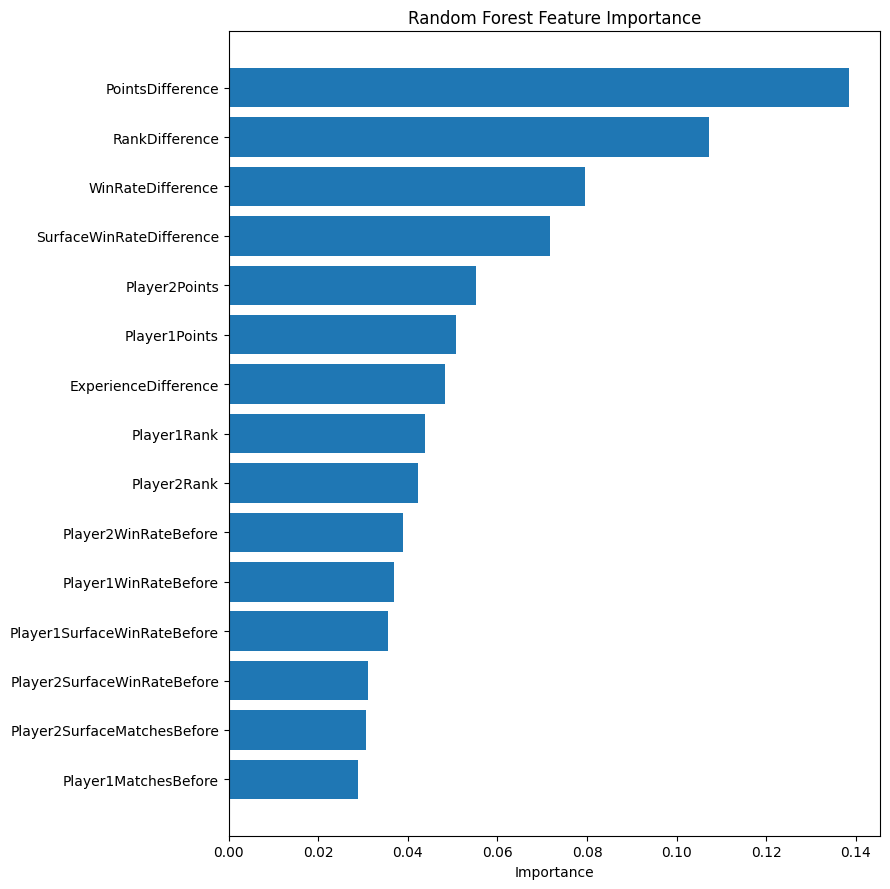

In [20]:
top_features = (
    feature_importance.head(15).sort_values(
        by="Importance", ascending=True
    )
)

plt.figure(figsize=(9, 9))
plt.barh(
    top_features["Feature"], 
    top_features["Importance"]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Feature importance

The strongest features are the differences between the two players, especially ranking points, ranking, previous win rate and surface win rate.

This is useful because several of the most important variables are features I created from earlier matches, not only the original ranking columns.  
The head-to-head features have much lower importance, probably because many pairs of players have little or no previous direct history.

In [21]:
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")

tuning_results.to_csv(
    RESULTS_DIR / "RF_tuning_results.csv", index=False
)

feature_importance.to_csv(
    RESULTS_DIR / "RF_feature_importance.csv", index=False
)


In [22]:
import joblib 

joblib.dump(best_model, MODELS_DIR / "best_RF_validation.joblib")

['../models/best_RF_validation.joblib']

In [23]:
# final tuning summary 
print(
    tuning_results[
        [
            "Model",
            "NumberOfTrees",
            "MaxDepth",
            "MinSamplesLeaf",
            "Accuracy",
            "BalancedAccuracy",
            "F1",
            "ROC_AUC",
            "LogLoss"
        ]
    ]
)

                    Model  NumberOfTrees  ...   ROC_AUC   LogLoss
0         RF 200 depth 10            200  ...  0.702871  0.625568
1  RF 300 depth 15 leaf 2            300  ...  0.696841  0.629398
2  RF 300 depth 10 leaf 2            300  ...  0.703241  0.624719
3         RF 200 depth 15            200  ...  0.695480  0.630588
4                  RF 200            200  ...  0.691082  0.633854
5                  RF 100            100  ...  0.684589  0.637336

[6 rows x 9 columns]


In [24]:
print(feature_importance.head(15))

                        Feature  Importance
0              PointsDifference    0.138495
1                RankDifference    0.107283
2             WinRateDifference    0.079517
3      SurfaceWinRateDifference    0.071633
4                 Player2Points    0.055134
5                 Player1Points    0.050808
6          ExperienceDifference    0.048261
7                   Player1Rank    0.043876
8                   Player2Rank    0.042267
9          Player2WinRateBefore    0.038939
10         Player1WinRateBefore    0.036906
11  Player1SurfaceWinRateBefore    0.035473
12  Player2SurfaceWinRateBefore    0.031172
13  Player2SurfaceMatchesBefore    0.030618
14         Player1MatchesBefore    0.028847
